# **Air Quality Analysis (India)**

This exploratory data analysis (EDA) project aims to examine the real-time air quality data sourced from [data.gov.in](https://data.gov.in/resource/real-time-air-quality-index-various-locations). The goal is to uncover meaningful insights about air pollution levels across Indian cities using Python-based analysis and visualization tools.

## **Objectives**

1. Compare average pollution levels across Indian states and cities.
2. Analyze correlations among pollutant metrics.
3. Identify and visualize the most polluted monitoring stations.
4. Regional Pollution Patterns and Dominant Pollutants Across India.
5. Visualize spatial distribution using geographic coordinates.

## **Tools & Libraries**
We will use the following libraries for data processing and visualization:

- `Pandas` for data manipulation  
- `NumPy` for numerical operations  
- `Matplotlib` & `Seaborn` for plotting  
- `Jupyter Notebook` for step-by-step exploration


## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Loading and displaying the data

In [3]:
file_path = '../data/air_quality_data.csv'
data = pd.read_csv(file_path)

In [4]:
print("Original Data Preview:")
data.head()

Original Data Preview:


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Vijayawada,"HB Colony, Vijayawada - APPCB",05-04-2025 21:00:00,16.536107,80.594233,CO,16.0,35.0,26.0
1,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",05-04-2025 21:00:00,16.486692,80.699436,OZONE,24.0,43.0,37.0
2,India,Andhra_Pradesh,Vijayawada,"Rajiv Gandhi Park, Vijayawada - APPCB",05-04-2025 21:00:00,16.509717,80.612222,PM2.5,62.0,95.0,81.0
3,India,Andhra_Pradesh,Vijayawada,"Rajiv Gandhi Park, Vijayawada - APPCB",05-04-2025 21:00:00,16.509717,80.612222,NO2,49.0,66.0,56.0
4,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",05-04-2025 21:00:00,16.554731,80.649110,OZONE,34.0,112.0,51.0


In [5]:
print("Data Shape:")
data.shape

Data Shape:


(3229, 11)

In [6]:
print("Missing Values:")
data.isnull().sum()

Missing Values:


country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    224
pollutant_max    224
pollutant_avg    224
dtype: int64

## Data Cleaning and Preprocessing

In [7]:
print("Column names and data types:")
data.info()

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3229 entries, 0 to 3228
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3229 non-null   object 
 1   state          3229 non-null   object 
 2   city           3229 non-null   object 
 3   station        3229 non-null   object 
 4   last_update    3229 non-null   object 
 5   latitude       3229 non-null   float64
 6   longitude      3229 non-null   float64
 7   pollutant_id   3229 non-null   object 
 8   pollutant_min  3005 non-null   float64
 9   pollutant_max  3005 non-null   float64
 10  pollutant_avg  3005 non-null   float64
dtypes: float64(5), object(6)
memory usage: 277.6+ KB


In [8]:
duplicates = data.duplicated().sum() # Checking for duplicate rows
print(f"Number of Duplicate Rows: {duplicates}")

Number of Duplicate Rows: 0


In [9]:
if duplicates > 0:
    data = data.drop_duplicates() # Dropping duplicate rows
    print(f"Dropped {duplicates} duplicate rows.")

In [10]:
data.isnull().sum() # Checking for missing values in each column

country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    224
pollutant_max    224
pollutant_avg    224
dtype: int64

In [11]:
data = data.dropna(subset=['pollutant_min', 'pollutant_max', 'pollutant_avg'])
print(f"Rows with missing pollutant values dropped. Remaining rows: {data.shape[0]}")

Rows with missing pollutant values dropped. Remaining rows: 3005


In [12]:
data.info() # Checking for data types and null values

<class 'pandas.core.frame.DataFrame'>
Index: 3005 entries, 0 to 3228
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3005 non-null   object 
 1   state          3005 non-null   object 
 2   city           3005 non-null   object 
 3   station        3005 non-null   object 
 4   last_update    3005 non-null   object 
 5   latitude       3005 non-null   float64
 6   longitude      3005 non-null   float64
 7   pollutant_id   3005 non-null   object 
 8   pollutant_min  3005 non-null   float64
 9   pollutant_max  3005 non-null   float64
 10  pollutant_avg  3005 non-null   float64
dtypes: float64(5), object(6)
memory usage: 281.7+ KB


In [13]:
print("\nUnique Values in Each Column:")
for col in data.columns:
    print(f"{col}: {data[col].nunique()} unique values")



Unique Values in Each Column:
country: 1 unique values
state: 32 unique values
city: 253 unique values
station: 482 unique values
last_update: 1 unique values
latitude: 482 unique values
longitude: 482 unique values
pollutant_id: 7 unique values
pollutant_min: 129 unique values
pollutant_max: 357 unique values
pollutant_avg: 201 unique values


In [14]:
# since the columns country and last_update have the same value in all rows and are not useful for analysis, we will drop them
data = data.drop(columns=['country', 'last_update'])

In [15]:
print("Basic Statistics of the Cleaned Data:")
data.describe()

Basic Statistics of the Cleaned Data:


,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3005.000000,3005.000000,3005.000000,3005.000000,3005.000000
mean,22.342621,78.873794,24.221963,83.195008,46.959401
std,5.499506,5.040363,26.534736,83.834664,43.953519
min,8.514909,70.909168,1.000000,1.000000,1.000000
25%,19.057575,75.578914,6.000000,21.000000,13.000000
50%,23.142888,77.508730,14.000000,58.000000,32.000000
75%,26.786682,81.005119,34.000000,115.000000,69.000000
max,34.066206,94.636574,222.000000,491.000000,303.000000


In [16]:
print("Cleaned Data Preview:")
data.head()

Cleaned Data Preview:


,state,city,station,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,Andhra_Pradesh,Vijayawada,"HB Colony, Vijayawada - APPCB",16.536107,80.594233,CO,16.0,35.0,26.0
1,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",16.486692,80.699436,OZONE,24.0,43.0,37.0
2,Andhra_Pradesh,Vijayawada,"Rajiv Gandhi Park, Vijayawada - APPCB",16.509717,80.612222,PM2.5,62.0,95.0,81.0
3,Andhra_Pradesh,Vijayawada,"Rajiv Gandhi Park, Vijayawada - APPCB",16.509717,80.612222,NO2,49.0,66.0,56.0
4,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",16.554731,80.649110,OZONE,34.0,112.0,51.0


## Exploratory Data Analysis (EDA)

In [17]:
print("1. SUMMARY STATISTICS")
pollutant_stats = data.groupby('pollutant_id')[['pollutant_min', 'pollutant_max', 'pollutant_avg']].describe()
pollutant_stats

1. SUMMARY STATISTICS


pollutant_min                                                \
                     count       mean        std  min   25%   50%    75%   
pollutant_id                                                               
CO                   461.0  19.950108  16.417505  1.0   9.0  16.0  26.00   
NH3                  386.0   4.134715   3.186414  1.0   2.0   3.0   6.00   
NO2                  432.0  17.625000  16.292231  1.0   7.0  13.0  22.25   
OZONE                445.0  14.278652  16.968801  1.0   3.0   9.0  19.00   
PM10                 431.0  63.067285  30.538236  1.0  42.0  63.0  82.00   
PM2.5                433.0  37.685912  24.413267  2.0  20.0  35.0  52.00   
SO2                  417.0  10.853717  11.615440  1.0   4.0   7.0  14.00   

                    pollutant_max              ...                \
                max         count        mean  ...    75%    max   
pollutant_id                                   ...                 
CO            106.0         461.0   66.182213  ...   95.0  175.0   
NH3            20.0         386.0    9.031088  ...   11.0   78.0   
NO2           116.0         432.0   59.530093  ...   88.0  390.0   
OZONE         159.0         445.0   78.512360  ...  108.0  346.0   
PM10          167.0         431.0  166.867749  ...  197.5  491.0   
PM2.5         222.0         433.0  161.452656  ...  241.0  461.0   
SO2           106.0         417.0   32.424460  ...   44.0  137.0   

             pollutant_avg                                                 \
                     count       mean        std  min    25%   50%    75%   
pollutant_id                                                                
CO                   461.0  35.626898  24.518486  3.0  20.00  29.0   45.0   
NH3                  386.0   5.865285   4.554716  1.0   2.25   5.0    8.0   
NO2                  432.0  30.865741  23.592844  1.0  14.00  25.0   40.0   
OZONE                445.0  54.298876  38.684309  1.0  24.00  49.0   74.0   
PM10                 431.0  99.162413  42.036934  5.0  72.00  99.0  123.0   
PM2.5                433.0  79.993072  46.350291  5.0  47.00  69.0  103.0   
SO2                  417.0  18.110312  14.348925  1.0   9.00  15.0   23.0   

                     
                max  
pollutant_id         
CO            175.0  
NH3            34.0  
NO2           148.0  
OZONE         303.0  
PM10          276.0  
PM2.5         302.0  
SO2           108.0  

[7 rows x 24 columns]

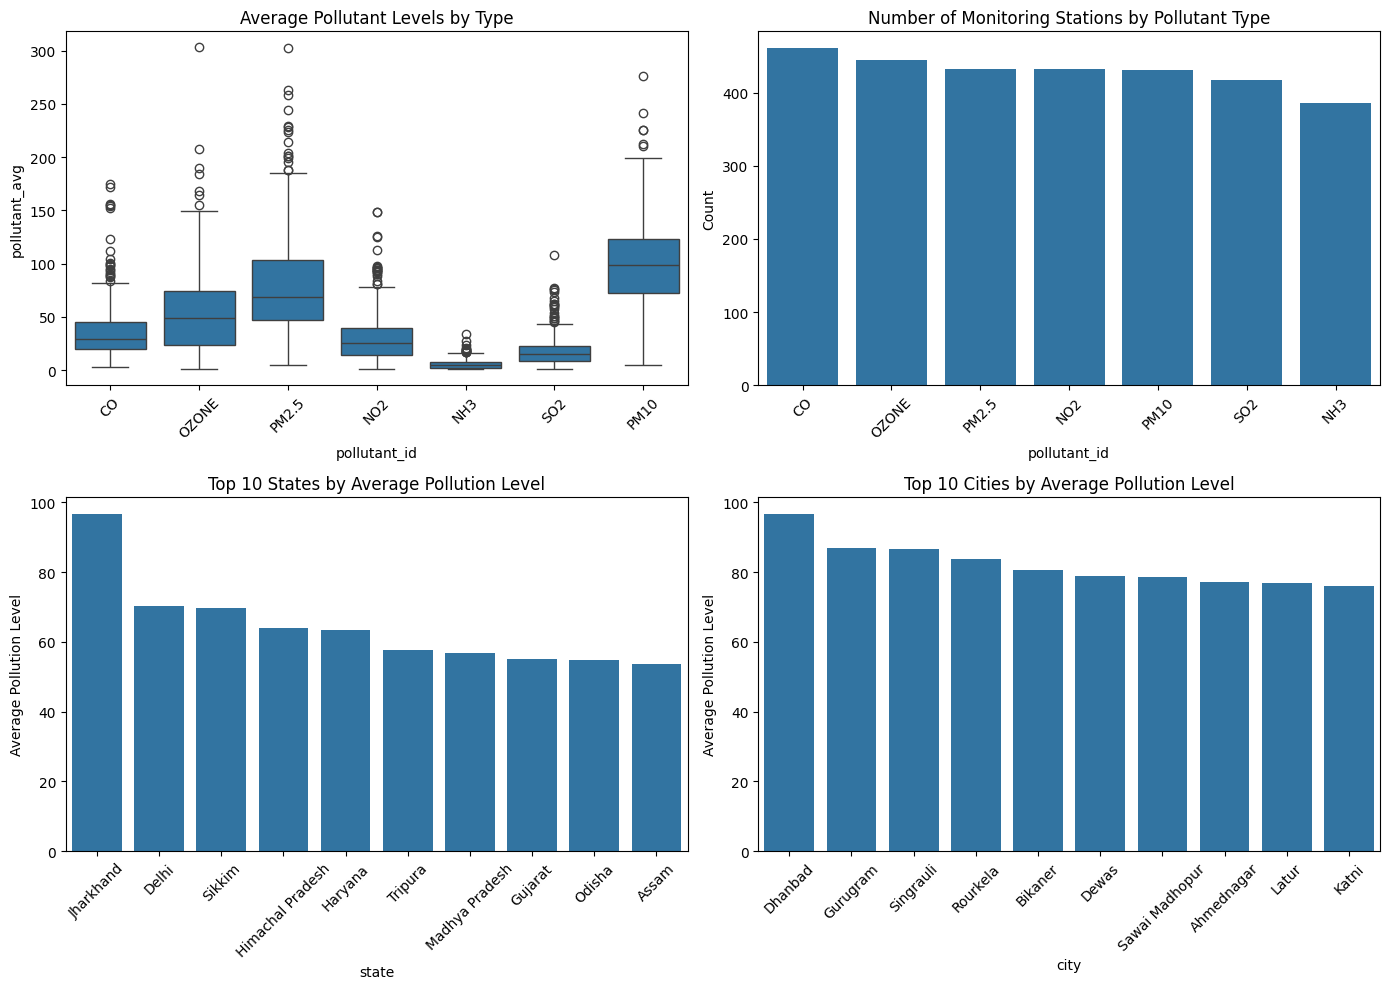

In [18]:
# Distribution of Pollutants
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # 4 plots in a 2x2 grid

# Boxplot
sns.boxplot(ax=axes[0, 0], x='pollutant_id', y='pollutant_avg', data=data)
axes[0, 0].set_title('Average Pollutant Levels by Type')
axes[0, 0].tick_params(axis='x', rotation=45)

# Barplot of Pollutant Counts
pollutant_counts = data['pollutant_id'].value_counts()
sns.barplot(ax=axes[0, 1], x=pollutant_counts.index, y=pollutant_counts.values)
axes[0, 1].set_title('Number of Monitoring Stations by Pollutant Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Top States
top_states = data.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10)
sns.barplot(ax=axes[1, 0], x=top_states.index, y=top_states.values)
axes[1, 0].set_title('Top 10 States by Average Pollution Level')
axes[1, 0].set_ylabel('Average Pollution Level')
axes[1, 0].tick_params(axis='x', rotation=45)

# Top Cities
top_cities = data.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)
sns.barplot(ax=axes[1, 1], x=top_cities.index, y=top_cities.values)
axes[1, 1].set_title('Top 10 Cities by Average Pollution Level')
axes[1, 1].set_ylabel('Average Pollution Level')
axes[1, 1].tick_params(axis='x', rotation=45)

fig.tight_layout()

plt.savefig('pollution_overview.png', dpi=300, bbox_inches='tight')
plt.show()



Conclusion:
This four-panel visualization provides comprehensive insights into India's air quality landscape. The top-left boxplot reveals that PM10 has the highest median concentration (~100 μg/m³) with extreme outliers reaching nearly 300 μg/m³, followed by PM2.5, indicating that particulate pollution is the most severe air quality challenge across the country. The top-right plot shows that CO has the most monitoring stations, reflecting its priority in national air quality monitoring programs. The bottom panels identify critical geographic pollution hotspots with Jharkhand emerging as the most polluted state with average levels nearly 30% higher than Delhi, the second-most polluted state. At the city level, Dhanbad leads with the highest average pollution, followed by Gurgram and Singrauli, all industrial centers with significant mining or manufacturing activities. This geographical distribution highlights the correlation between industrial activity and air pollution severity. The data underscores the need for enhanced pollution control measures in industrial corridors and suggests that particulate matter should be the primary focus of air quality management strategies.

## Objective 1: Compare Pollution Across Indian States and Cities

In [19]:
# Create a hierarchical index
# Aggregate data at different levels
state_pollution = data.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False)
city_pollution = data.groupby(['state', 'city'])['pollutant_avg'].mean().sort_values(ascending=False)
station_pollution = data.groupby(['state', 'city', 'station'])['pollutant_avg'].mean().sort_values(ascending=False)

In [20]:
# Display top 10 most polluted states
print("\nTop 10 Most Polluted States:")
print(state_pollution.head(10))


Top 10 Most Polluted States:
state
Jharkhand           96.600000
Delhi               70.429787
Sikkim              69.833333
Himachal Pradesh    64.000000
Haryana             63.333333
Tripura             57.714286
Madhya Pradesh      56.947712
Gujarat             55.166667
Odisha              54.915966
Assam               53.732143
Name: pollutant_avg, dtype: float64


In [21]:
# Display top 10 most polluted cities
print("\nTop 10 Most Polluted Cities:")
print(city_pollution.head(10))


Top 10 Most Polluted Cities:
state           city          
Jharkhand       Dhanbad           96.600000
Haryana         Gurugram          86.800000
Madhya Pradesh  Singrauli         86.714286
Odisha          Rourkela          83.666667
Rajasthan       Bikaner           80.714286
Madhya Pradesh  Dewas             78.857143
Rajasthan       Sawai Madhopur    78.714286
Maharashtra     Ahmednagar        77.142857
                Latur             77.000000
Madhya Pradesh  Katni             76.000000
Name: pollutant_avg, dtype: float64


In [22]:
# Display top 10 most polluted stations
print("\nTop 10 Most Polluted Stations:")
print(station_pollution.head(10))


Top 10 Most Polluted Stations:
state          city           station                                  
Maharashtra    Mumbai         Deonar, Mumbai - IITM                        134.000000
Delhi          Delhi          CRRI Mathura Road, Delhi - IMD               112.800000
                              North Campus, DU, Delhi - IMD                103.800000
                              Jahangirpuri, Delhi - DPCC                   100.857143
                              Ashok Vihar, Delhi - DPCC                     99.000000
Odisha         Rourkela       Raghunathpali, Rourkela - OSPCB               98.285714
Assam          Guwahati       Railway Colony, Guwahati - PCBA               98.000000
Jharkhand      Dhanbad        Sardar Patel Nagar, Dhanbad - JSPCB           96.600000
Delhi          Delhi          Wazirpur, Delhi - DPCC                        95.857143
Uttar_Pradesh  Greater Noida  Knowledge Park - V, Greater Noida - UPPCB     92.428571
Name: pollutant_avg, dtype: float64


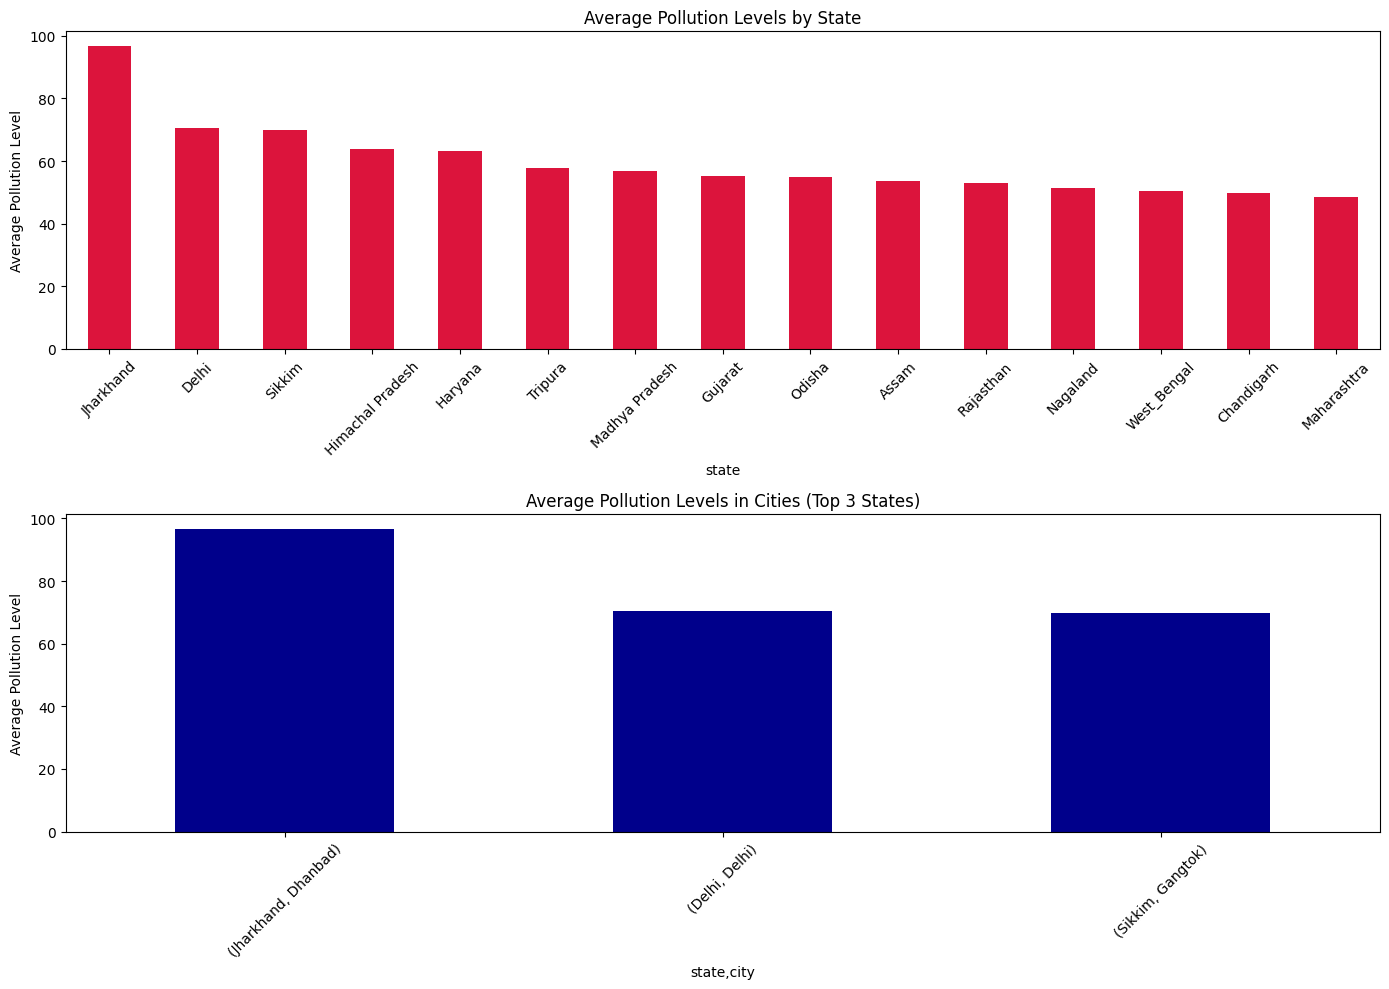

In [23]:
# Visualize state-level pollution
plt.figure(figsize=(14, 10))
    
# Plot pollution by state
plt.subplot(2, 1, 1)
state_pollution.head(15).plot(kind='bar', color='crimson')
plt.title('Average Pollution Levels by State')
plt.ylabel('Average Pollution Level')
plt.xticks(rotation=45)

# Plot top cities from the top 3 most polluted states
plt.subplot(2, 1, 2)
top_states = state_pollution.head(3).index
top_cities_data = city_pollution[city_pollution.index.get_level_values('state').isin(top_states)]
top_cities_data.head(15).plot(kind='bar', color='darkblue')
plt.title('Average Pollution Levels in Cities (Top 3 States)')
plt.ylabel('Average Pollution Level')
plt.xticks(rotation=45)
  
plt.tight_layout()
plt.savefig('hierarchical_pollution.png', dpi=300, bbox_inches='tight')
plt.show()

## Objective 2: Analyze correlations among pollutant metrics.


1. MIN/MAX/AVG RELATIONSHIPS


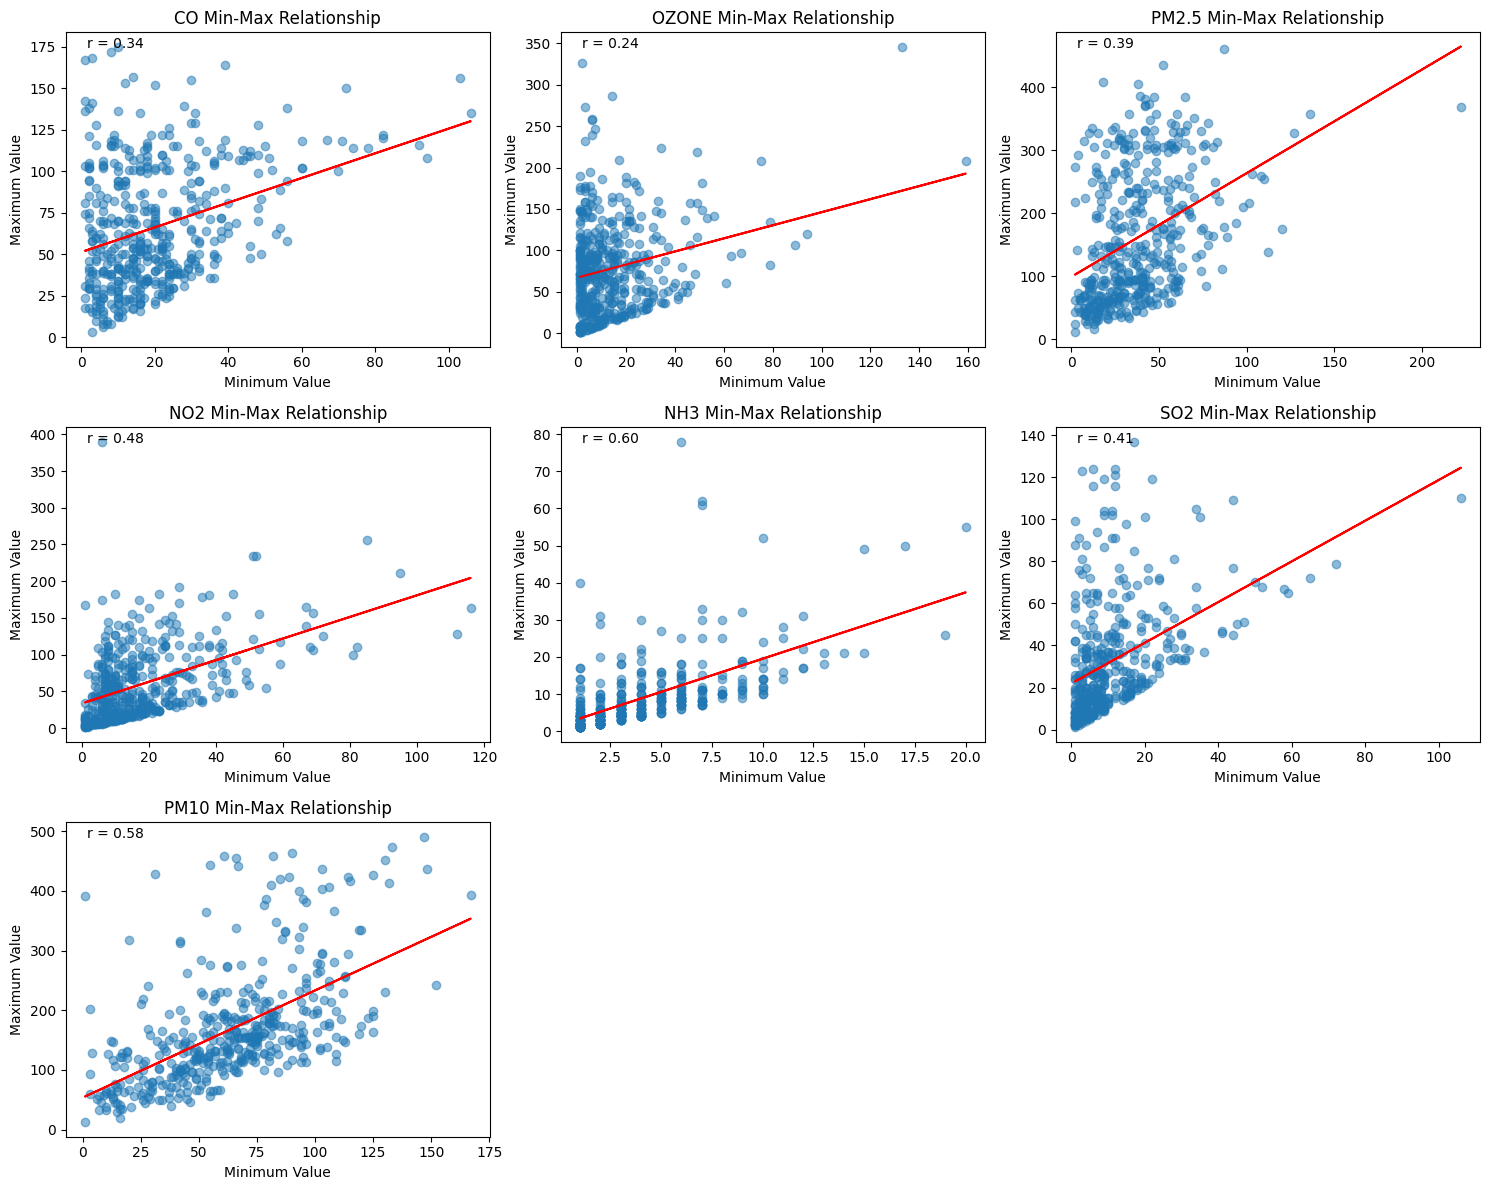

In [24]:
print("\n1. MIN/MAX/AVG RELATIONSHIPS")
import math

pollutants = data['pollutant_id'].unique()
n = len(pollutants)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

for i, pollutant in enumerate(pollutants):
    plt.subplot(rows, cols, i + 1)
    pollutant_data = data[data['pollutant_id'] == pollutant]
    plt.scatter(pollutant_data['pollutant_min'], pollutant_data['pollutant_max'], alpha=0.5)
    plt.xlabel('Minimum Value')
    plt.ylabel('Maximum Value')
    plt.title(f'{pollutant} Min-Max Relationship')

    x = pollutant_data['pollutant_min']
    y = pollutant_data['pollutant_max']
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color='red')

    corr = np.corrcoef(x, y)[0, 1]
    plt.annotate(f"r = {corr:.2f}", xy=(0.05, 0.95), xycoords='axes fraction')

plt.tight_layout()
plt.savefig('min_max_relationships_all.png', dpi=300, bbox_inches='tight')
plt.show()


Conclusion:
The scatter plots reveal important patterns in the fluctuation patterns of different air pollutants across India. NH3 exhibits the strongest correlation (r = 0.60) between minimum and maximum values, indicating consistent and predictable concentration variations. PM10 also shows a relatively strong relationship (r = 0.58), suggesting that when baseline levels increase, peak concentrations rise proportionally. For NO2 (r = 0.48) and SO2 (r = 0.41), the moderate correlations suggest some predictability but with greater variability. Notably, OZONE displays the weakest correlation (r = 0.24), indicating that its peak concentrations can spike significantly regardless of baseline levels, likely due to its complex photochemical formation processes that depend on multiple factors beyond initial concentrations. The differing correlation strengths across pollutants highlight the need for pollutant-specific monitoring and management strategies, as each shows distinct behavior patterns between their minimum and maximum concentrations.

In [25]:
# Calculate and display min/max/avg correlations for each pollutant
print("\nCorrelations between Min, Max, and Avg for each pollutant:")
for pollutant in data['pollutant_id'].unique():
        pollutant_data = data[data['pollutant_id'] == pollutant]
        corr_matrix = pollutant_data[['pollutant_min', 'pollutant_max', 'pollutant_avg']].corr()
        print(f"\n{pollutant} Correlation Matrix:")
        print(corr_matrix)


Correlations between Min, Max, and Avg for each pollutant:

CO Correlation Matrix:
               pollutant_min  pollutant_max  pollutant_avg
pollutant_min       1.000000       0.336541       0.631996
pollutant_max       0.336541       1.000000       0.727420
pollutant_avg       0.631996       0.727420       1.000000

OZONE Correlation Matrix:
               pollutant_min  pollutant_max  pollutant_avg
pollutant_min       1.000000        0.23813       0.414794
pollutant_max       0.238130        1.00000       0.917870
pollutant_avg       0.414794        0.91787       1.000000

PM2.5 Correlation Matrix:
               pollutant_min  pollutant_max  pollutant_avg
pollutant_min       1.000000       0.392424       0.690223
pollutant_max       0.392424       1.000000       0.833858
pollutant_avg       0.690223       0.833858       1.000000

NO2 Correlation Matrix:
               pollutant_min  pollutant_max  pollutant_avg
pollutant_min       1.000000       0.479885       0.847541
pollutant_m


2. CROSS-POLLUTANT ANALYSIS

Correlation between different pollutants (where data is available):
pollutant_id       NH3       NO2     OZONE      PM10     PM2.5       SO2
pollutant_id                                                            
NH3           1.000000  0.384843  0.244095  0.316936  0.187557 -0.012414
NO2           0.384843  1.000000  0.152640  0.280521  0.224983  0.098004
OZONE         0.244095  0.152640  1.000000  0.285843  0.067221 -0.039984
PM10          0.316936  0.280521  0.285843  1.000000  0.743042  0.147365
PM2.5         0.187557  0.224983  0.067221  0.743042  1.000000  0.173768
SO2          -0.012414  0.098004 -0.039984  0.147365  0.173768  1.000000


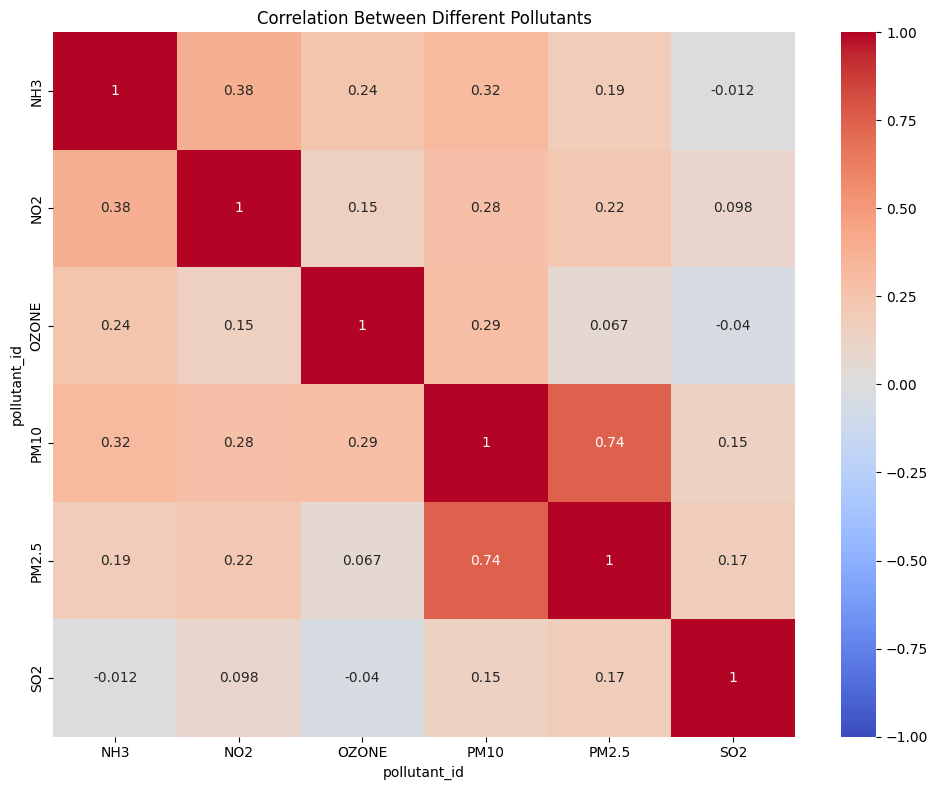

In [26]:
print("\n2. CROSS-POLLUTANT ANALYSIS")

# Step 1: Create pivot table with average values for each pollutant per location+date
pivot_data = data.pivot_table(
    index=['state', 'city'], 
    columns='pollutant_id', 
    values='pollutant_avg'
).reset_index()

# Step 2: Check if we have enough pollutants to analyze
if pivot_data is not None and len(pivot_data.columns) > 3:
    pollutant_cols = pivot_data.columns[3:]  # Skip index columns

    # Filter out pollutants with too many NaNs
    available_pollutants = [
        col for col in pollutant_cols if pivot_data[col].notna().sum() > 5
    ]

    if len(available_pollutants) >= 2:
        print("\nCorrelation between different pollutants (where data is available):")
        corr_matrix = pivot_data[available_pollutants].corr()
        print(corr_matrix)

        # Step 3: Plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Correlation Between Different Pollutants')
        plt.tight_layout()
        plt.savefig('cross_pollutant_correlation.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Not enough pollutant data to compute meaningful correlations.")
else:
    print("Pivot table could not be constructed properly.")

Conclusion:
This heatmap reveals important relationships between various air pollutants across India's monitoring stations. The most significant findings include:
The strongest correlation (0.74) exists between PM10 and PM2.5, indicating these particulate pollutants typically occur together. This strong relationship makes sense given that PM2.5 is a subset of PM10, and they often share common sources such as combustion processes, vehicle emissions, and industrial activities.
NH3 and NO2 show a moderate correlation (0.38), suggesting some common sources or formation mechanisms between these nitrogen-based compounds. These pollutants are typically associated with agricultural activities, industrial processes, and vehicle emissions.
Most other pollutant pairs exhibit weak positive correlations (0.15-0.32), indicating some relationship but considerable independence in their occurrence patterns. This suggests differing source contributions and formation mechanisms.
Notably, SO2 has very weak correlations with all other pollutants, including slight negative relationships with NH3 (-0.012) and OZONE (-0.04). This independence suggests SO2's sources (primarily industrial and power generation) operate differently from other pollution sources.
OZONE shows generally weak correlations with other primary pollutants, reflecting its nature as a secondary pollutant formed through photochemical reactions rather than direct emissions.
These correlation patterns have important implications for pollution control strategies. The strong PM10-PM2.5 relationship suggests that interventions targeting one will likely affect the other. Conversely, the independence of SO2 indicates that specific control measures focused on industrial emissions would be needed to address this pollutant without significantly impacting others.

## Objective 3: Identify and visualize the most polluted monitoring stations.

In [27]:
# Rank stations by average pollutant levels
station_avg = data.groupby(['station', 'pollutant_id'])['pollutant_avg'].mean().reset_index()

# Get the most polluted station for each pollutant
most_polluted_by_type = station_avg.sort_values('pollutant_avg', ascending=False).groupby('pollutant_id').head(1)

print("\nMost Polluted Station by Pollutant Type:")
most_polluted_by_type


Most Polluted Station by Pollutant Type:


,station,pollutant_id,pollutant_avg
149,"Bardowali, Agartala - Tripura SPCB",OZONE,303.0
2108,"Raghunathpali, Rourkela - OSPCB",PM2.5,302.0
1642,"Muradpur, Patna - BSPCB",PM10,276.0
1404,"MM Ground, Bikaner - RSPCB",CO,175.0
1490,"Mandir Marg, Delhi - DPCC",NO2,148.0
501,"DM College of Science, Imphal - Manipur PCB",SO2,108.0
1891,"Park Street Wakad, Pimpri Chinchwad - MPCB",NH3,34.0


In [28]:
# Get the top 10 most polluted stations overall
most_polluted_overall = station_avg.sort_values('pollutant_avg', ascending=False).head(10)

print("\nTop 10 Most Polluted Stations Overall:")
most_polluted_overall


Top 10 Most Polluted Stations Overall:


,station,pollutant_id,pollutant_avg
149,"Bardowali, Agartala - Tripura SPCB",OZONE,303.0
2108,"Raghunathpali, Rourkela - OSPCB",PM2.5,302.0
1642,"Muradpur, Patna - BSPCB",PM10,276.0
1272,"Knowledge Park - V, Greater Noida - UPPCB",PM2.5,263.0
2128,"Railway Colony, Guwahati - PCBA",PM2.5,258.0
847,"Gyaspur, Ahmedabad - IITM",PM2.5,244.0
1628,"Mundka, Delhi - DPCC",PM10,241.0
567,"Deen Dayal Nagar, Gwalior - MPPCB",PM2.5,229.0
1001,"Industrial Area, Hajipur - BSPCB",PM2.5,228.0
1025,"Jahangirpuri, Delhi - DPCC",PM10,225.0


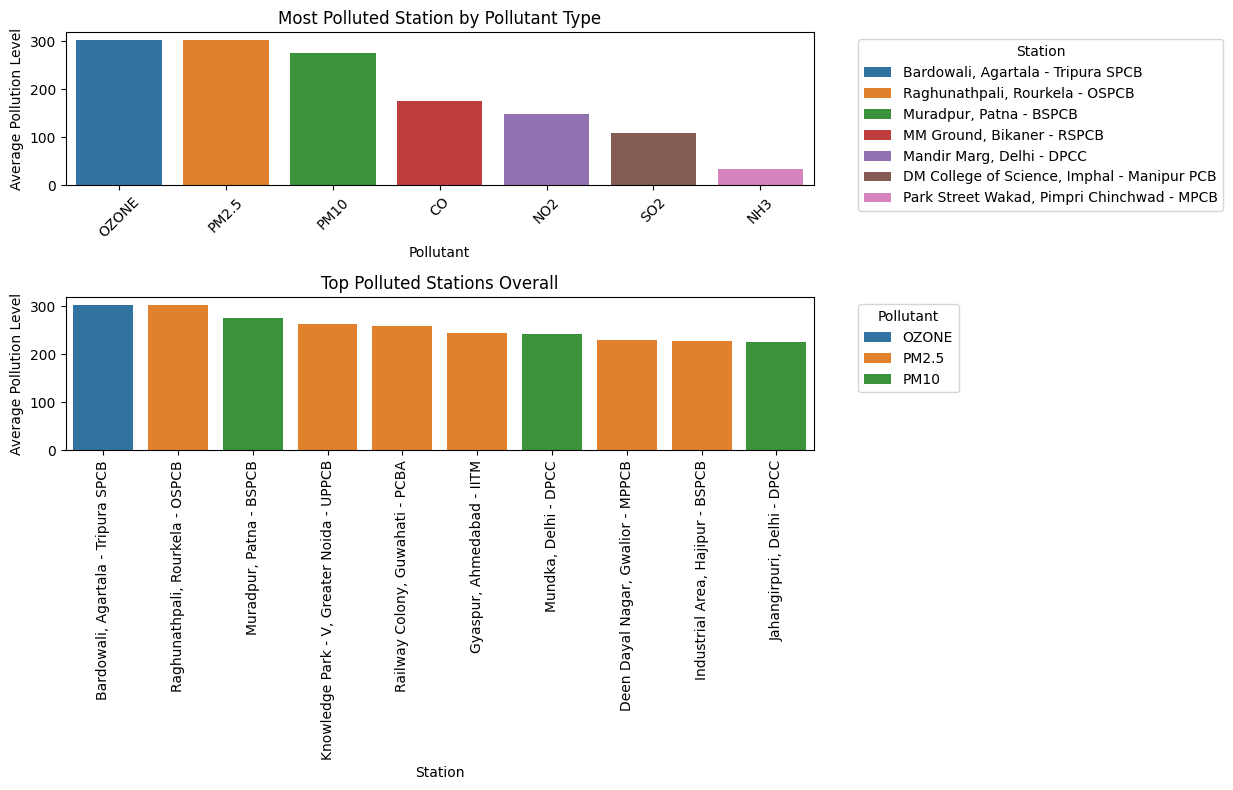

In [29]:
# Visualize the most polluted stations
plt.figure(figsize=(14, 8))

# Plot most polluted station by pollutant type
plt.subplot(2, 1, 1)
sns.barplot(x='pollutant_id', y='pollutant_avg', hue='station', data=most_polluted_by_type)
plt.title('Most Polluted Station by Pollutant Type')
plt.xlabel('Pollutant')
plt.ylabel('Average Pollution Level')
plt.legend(title='Station', loc='upper left', bbox_to_anchor=(1.05, 1))  # Adjusted legend position
plt.xticks(rotation=45)

# Plot top polluted stations overall
plt.subplot(2, 1, 2)
sns.barplot(x='station', y='pollutant_avg', hue='pollutant_id', data=most_polluted_overall)
plt.title('Top Polluted Stations Overall')
plt.xlabel('Station')
plt.ylabel('Average Pollution Level')
plt.legend(title='Pollutant', loc='upper left', bbox_to_anchor=(1.05, 1))  # Adjusted legend position
plt.xticks(rotation=90)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make space for the legend
plt.savefig('most_polluted_stations.png', dpi=300, bbox_inches='tight')
plt.show()

Conclusion:
This dual-panel visualization reveals critical information about pollution hotspots across India. The top panel identifies the most severely affected monitoring stations for each pollutant type, with Bardowali (Agartala) recording alarming OZONE levels around 300 units, Raghunathpali (Rourkela) showing equally concerning PM2.5 concentrations, and Muradpur (Patna) registering significant PM10 levels. These findings highlight how different pollutants dominate in different regions, likely reflecting varying emission sources and local conditions. The bottom panel, displaying the top polluted stations overall, demonstrates that particulate matter (PM2.5 and PM10) and OZONE are the most problematic pollutants nationwide, with eastern and northern stations (particularly in Tripura, Odisha, Bihar, and Delhi) consistently appearing in the most affected list. This geographic clustering suggests regional industrial activities, traffic patterns, or meteorological conditions may be contributing factors. The data points to the need for targeted intervention strategies in these high-pollution areas, especially focused on particulate matter and ozone management.

## Objective 4: Regional Pollution Patterns and Dominant Pollutants Across India

=== TOP THREE POLLUTANTS BY REGION ANALYSIS ===

Top 3 Pollutants by Region:

Central India:
  1. PM10: 100.42
  2. PM2.5: 78.97
  3. OZONE: 53.76

East India:
  1. PM10: 112.20
  2. PM2.5: 101.71
  3. OZONE: 52.37

North India:
  1. PM10: 116.93
  2. PM2.5: 94.80
  3. OZONE: 65.61

South India:
  1. PM10: 50.21
  2. PM2.5: 40.32
  3. CO: 28.22

West India:
  1. PM10: 107.17
  2. PM2.5: 79.38
  3. OZONE: 64.90


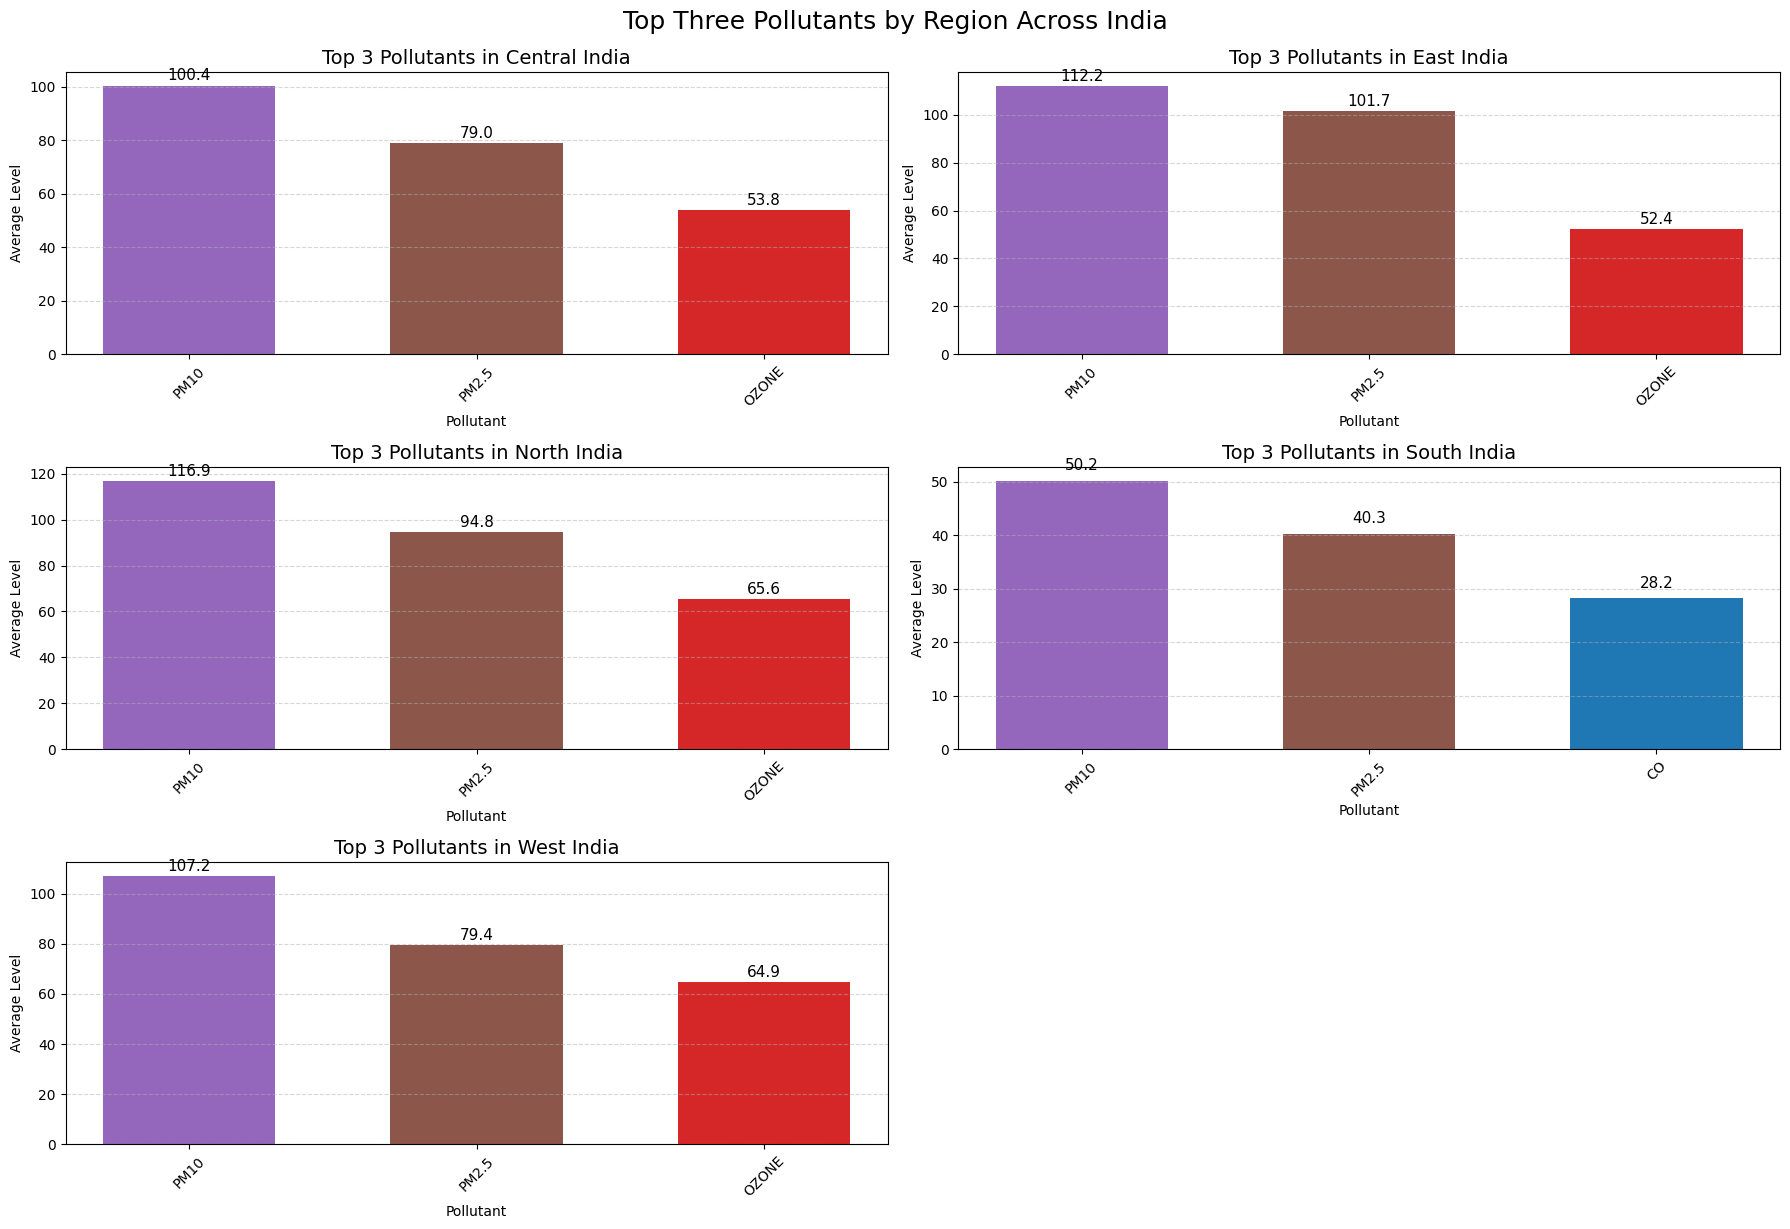

In [30]:
print("=== TOP THREE POLLUTANTS BY REGION ANALYSIS ===")

# Region mapping
region_dict = {
    'Jammu_and_Kashmir': 'North', 'Himachal Pradesh': 'North', 'Punjab': 'North',
    'Uttarakhand': 'North', 'Haryana': 'North', 'Delhi': 'North', 'Chandigarh': 'North',
    'Uttar_Pradesh': 'North',
    'Andhra_Pradesh': 'South', 'Telangana': 'South', 'Karnataka': 'South',
    'Kerala': 'South', 'TamilNadu': 'South', 'Puducherry': 'South',
    'Bihar': 'East', 'Jharkhand': 'East', 'Odisha': 'East', 'West_Bengal': 'East',
    'Sikkim': 'East', 'Assam': 'East', 'Arunachal_Pradesh': 'East', 'Nagaland': 'East',
    'Manipur': 'East', 'Mizoram': 'East', 'Tripura': 'East', 'Meghalaya': 'East',
    'Andaman and Nicobar': 'East',
    'Rajasthan': 'West', 'Gujarat': 'West', 'Maharashtra': 'West', 'Goa': 'West',
    'Madhya Pradesh': 'Central', 'Chhattisgarh': 'Central'
}

# Assign regions
data['region'] = data['state'].map(region_dict)

# Handle unclassified states
unclassified = data[data['region'].isna()]['state'].unique()
if len(unclassified) > 0:
    print(f"Warning: The following states were not classified into regions: {unclassified}")
    data.loc[data['region'].isna(), 'region'] = 'Unclassified'

# Group and find top 3 pollutants per region
region_pollutant_avg = data.groupby(['region', 'pollutant_id'])['pollutant_avg'].mean().reset_index()
top_pollutants_by_region = {
    region: grp.sort_values('pollutant_avg', ascending=False).head(3)
    for region, grp in region_pollutant_avg.groupby('region') if region != 'Unclassified'
}

# Print results
print("\nTop 3 Pollutants by Region:")
for region, df in top_pollutants_by_region.items():
    print(f"\n{region} India:")
    for i, (_, row) in enumerate(df.iterrows(), 1):
        print(f"  {i}. {row['pollutant_id']}: {row['pollutant_avg']:.2f}")

# Plotting top 3 pollutants per region
plt.figure(figsize=(18, 12))
regions = sorted(top_pollutants_by_region.keys())
pollutants = region_pollutant_avg['pollutant_id'].unique()
color_palette = plt.cm.tab10.colors
pollutant_colors = {p: color_palette[i % len(color_palette)] for i, p in enumerate(pollutants)}

for i, region in enumerate(regions):
    plt.subplot(3, 2, i + 1)
    region_df = top_pollutants_by_region[region]
    bars = plt.bar(
        region_df['pollutant_id'],
        region_df['pollutant_avg'],
        color=[pollutant_colors[p] for p in region_df['pollutant_id']],
        width=0.6
    )
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 2, f"{height:.1f}", ha='center', fontsize=11)
    plt.title(f"Top 3 Pollutants in {region} India", fontsize=14)
    plt.xlabel("Pollutant")
    plt.ylabel("Average Level")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle("Top Three Pollutants by Region Across India", fontsize=18, y=1.02)
plt.savefig("top_three_pollutants_by_region.png", dpi=300, bbox_inches="tight")
plt.show()



Conclusion:
This regional analysis reveals distinct pollution signatures across India's five geographic regions. PM10 consistently emerges as the dominant pollutant in all regions except South India, with alarmingly high levels in North India (116.9 units) and East India (112.2 units). These elevated PM10 concentrations likely reflect the combined impact of industrial emissions, construction activities, and natural dust sources. PM2.5 appears as the second most significant pollutant across all regions, with concentrations particularly concerning in North India (94.8 units). South India shows markedly lower pollution levels overall, with its highest PM10 concentration (50.2 units) being less than half of North India's level. Notably, South India is the only region where CO appears among the top three pollutants instead of ozone, possibly indicating different emission sources or meteorological conditions affecting pollutant formation. The relatively similar pollutant profiles across Central, East, North, and West India suggest common emission sources and dispersion patterns, while South India's distinct profile highlights the influence of geographic, meteorological, and developmental factors on regional air quality. These findings emphasize the need for regionally tailored pollution control strategies that address the specific dominant pollutants in each area.

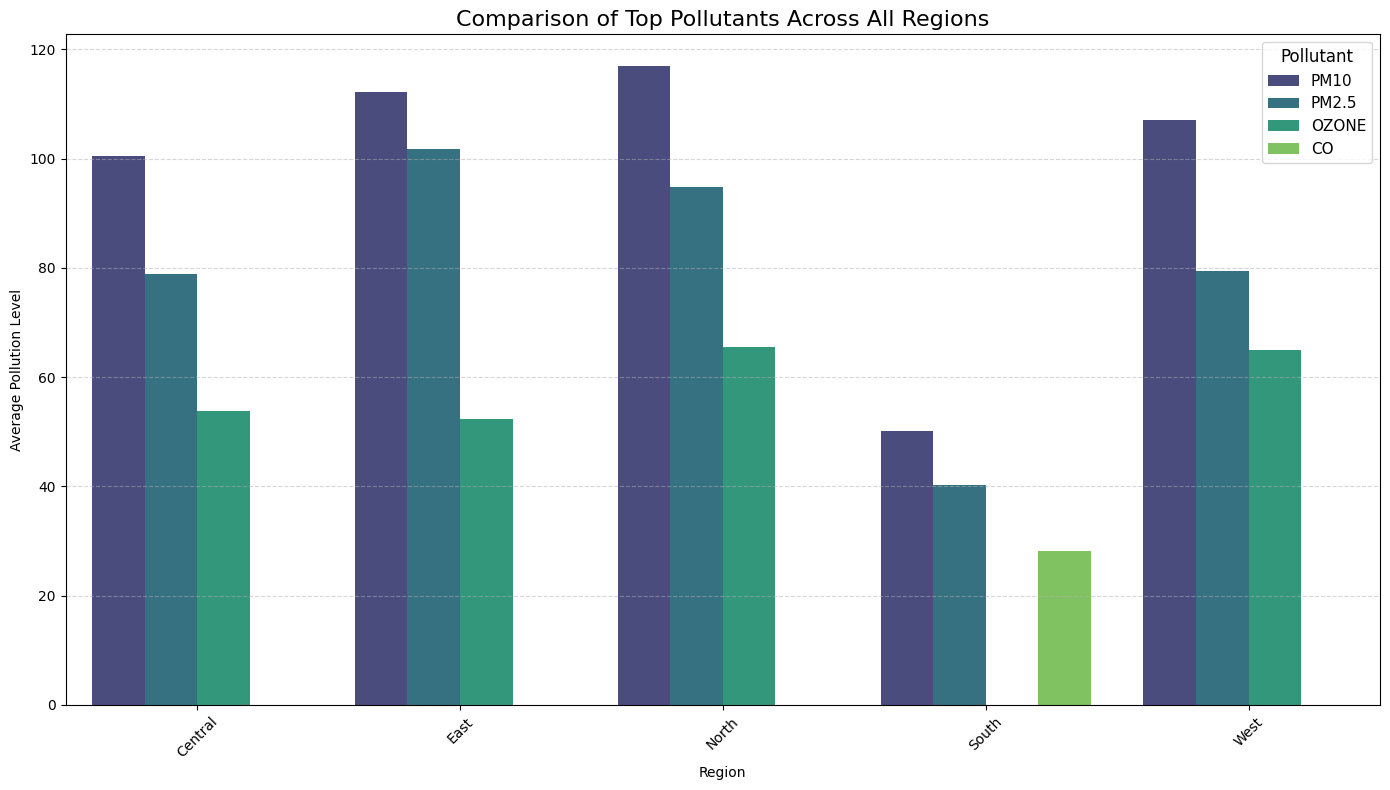

In [31]:
# Unified comparison chart
comparison_df = pd.concat([
    df.assign(Region=region) for region, df in top_pollutants_by_region.items()
])

plt.figure(figsize=(14, 8))
sns.barplot(
    x="Region", y="pollutant_avg", hue="pollutant_id",
    data=comparison_df, palette="viridis"
)
plt.title("Comparison of Top Pollutants Across All Regions", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Average Pollution Level")
plt.legend(title="Pollutant", fontsize=11, title_fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("region_pollutant_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Objective 5: Visualize spatial distribution using geographic coordinates.

=== SPATIAL DISTRIBUTION OF POLLUTION ===


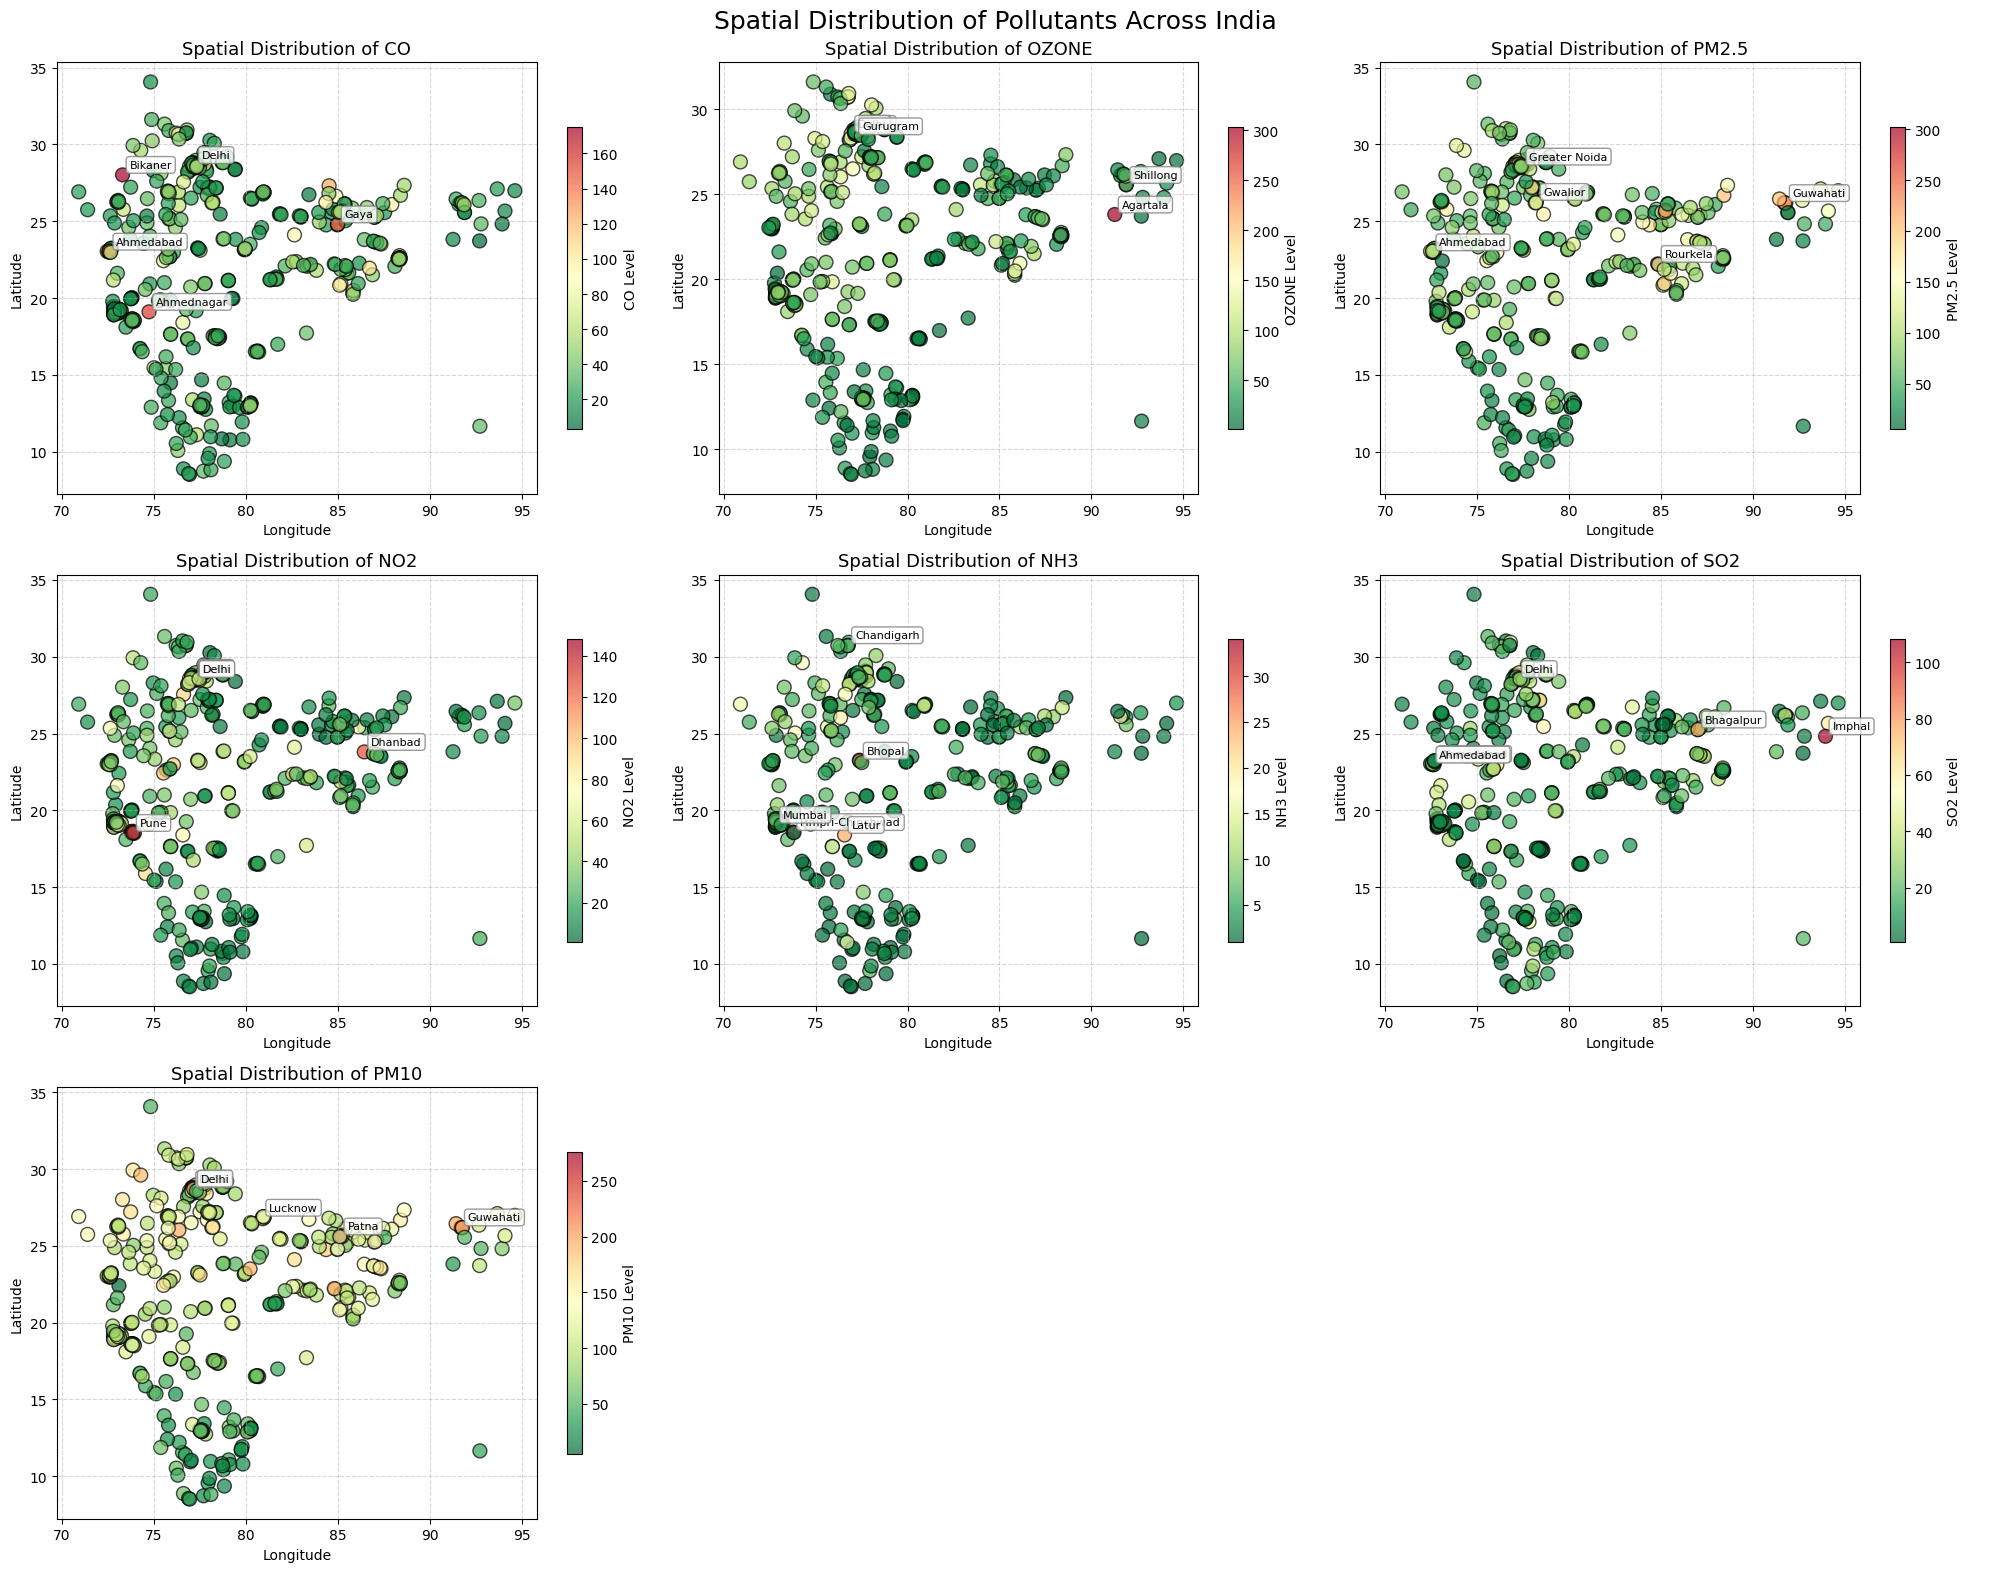

In [32]:
print("=== SPATIAL DISTRIBUTION OF POLLUTION ===")

# Identify pollutant types and filter those with enough data
pollutant_types = data['pollutant_id'].unique()

valid_pollutants = [
    pollutant for pollutant in pollutant_types
    if len(data[data['pollutant_id'] == pollutant]) >= 3
]

num_plots = len(valid_pollutants)

# Setup grid layout: 3 per row (i.e. 3, 3, 1 layout)
rows = 3
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(20, 16))
axes = axes.flatten()

# Hide unused subplots
for i in range(num_plots, len(axes)):
    axes[i].axis('off')

# Create plots
for i, pollutant in enumerate(valid_pollutants):
    ax = axes[i]
    pollutant_data = data[data['pollutant_id'] == pollutant]

    scatter = ax.scatter(
        pollutant_data['longitude'],
        pollutant_data['latitude'],
        c=pollutant_data['pollutant_avg'],
        cmap='RdYlGn_r',
        s=100,
        alpha=0.7,
        edgecolors='k'
    )

    ax.set_title(f'Spatial Distribution of {pollutant}', fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Add top 5 city labels
    top_cities = pollutant_data.sort_values('pollutant_avg', ascending=False).head(5)
    for _, row in top_cities.iterrows():
        ax.annotate(
            row['city'],
            (row['longitude'], row['latitude']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
        )

    # Add colorbar to each subplot
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
    cbar.set_label(f'{pollutant} Level')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.suptitle("Spatial Distribution of Pollutants Across India", fontsize=18)
plt.savefig("spatial_distribution_all_pollutants.png", dpi=300, bbox_inches='tight')
plt.show()


Conclusion:
The spatial distribution maps reveal distinct geographical patterns in air pollution across India. The northern regions, particularly around Delhi and the Indo-Gangetic plain, show consistently elevated levels across multiple pollutants, creating a visible "pollution corridor" that corresponds with India's most densely populated and industrialized belt. PM2.5 and PM10 concentrations are particularly concerning in this region, with hotspots appearing in cities like Delhi, Guwahati, and Lucknow. Ozone pollution shows a more dispersed pattern with significant concentrations in both northern and eastern regions, likely reflecting its secondary formation through photochemical reactions. Interestingly, SO2 pollution appears more localized around specific industrial centers, particularly in eastern and northern India. The southern regions consistently show lower pollution levels across all parameters, benefiting from coastal ventilation and potentially different industrial profiles. These spatial patterns highlight the need for region-specific pollution control strategies and suggest that trans-boundary pollution may be significant in the northern regions, requiring coordinated multi-state approaches to effectively address air quality challenges.